In [20]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

subset_dir = "medical_datasets/clean_tropical_cohort"

# 1. Load patient case reports
cases_df = pd.read_csv(os.path.join(subset_dir, "cases.csv"))

# 2. Load image-level metadata
# 2. Load image-level metadata (JSON Lines format)
images_df = pd.read_json(
    os.path.join(subset_dir, "image_metadata.json"), lines=True
)

print(f"Loaded {len(cases_df):,} patients and {len(images_df):,} images.")
print("\n--- Cases Columns ---")
print(cases_df.columns.tolist())
print("\n--- Image Metadata Columns ---")
print(images_df.columns.tolist())

Loaded 5,990 patients and 9,403 images.

--- Cases Columns ---
['case_id', 'pmcid', 'gender', 'age', 'case_text']

--- Image Metadata Columns ---
['file_id', 'file', 'file_path', 'main_image', 'case_id', 'license', 'file_size', 'split_during_preprocessing', 'caption', 'image_type', 'image_subtype', 'radiology_region', 'radiology_region_granular', 'radiology_view', 'ml_labels_for_supervised_classification', 'gt_labels_for_semisupervised_classification']


--- Gender Breakdown ---
gender
Male           3271
Female         2510
Unknown         206
Transgender       3
Name: count, dtype: int64

--- Age Summary ---
count    5746.000000
mean       39.103202
std        21.687221
min         0.000000
25%        23.000000
50%        39.000000
75%        56.000000
max        96.000000
Name: age, dtype: float64

--- Case Presentation Word Count Summary ---
count     5990.000000
mean       560.034891
std        401.216112
min         17.000000
25%        337.000000
50%        494.000000
75%        698.000000
90%        936.000000
95%       1130.650000
max      13899.000000
Name: word_count, dtype: float64


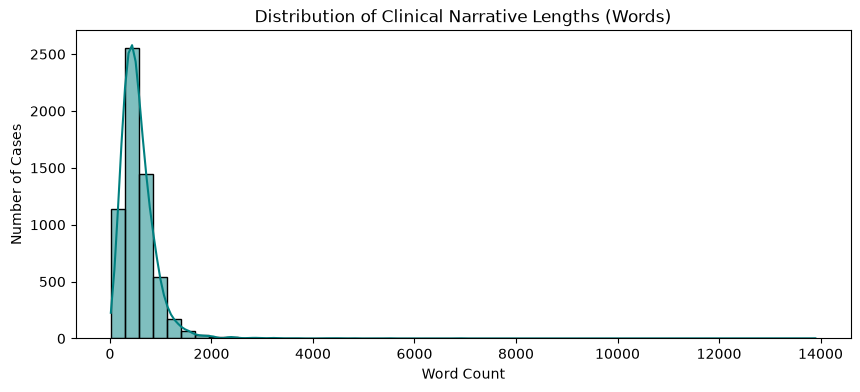

In [21]:
# Demographics
print("--- Gender Breakdown ---")
print(cases_df['gender'].value_counts(dropna=False))

print("\n--- Age Summary ---")
print(cases_df['age'].describe())

# Compute case text word length
cases_df['word_count'] = cases_df['case_text'].apply(lambda x: len(str(x).split()))

print("\n--- Case Presentation Word Count Summary ---")
print(cases_df['word_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]))

# Distribution plot
plt.figure(figsize=(10, 4))
sns.histplot(cases_df['word_count'], bins=50, kde=True, color='teal')
plt.title("Distribution of Clinical Narrative Lengths (Words)")
plt.xlabel("Word Count")
plt.ylabel("Number of Cases")
plt.show()

In [22]:
# 1. High-level modality distribution
if 'image_type' in images_df.columns:
    print("--- Top High-Level Modalities (image_type) ---")
    print(images_df['image_type'].value_counts().head(10))

# 2. Specific imaging subtype (X-ray, CT, MRI, ultrasound, histology, etc.)
if 'image_subtype' in images_df.columns:
    print("\n--- Top Specific Subtypes (image_subtype) ---")
    print(images_df['image_subtype'].value_counts().head(15))

# 3. Anatomical region
if 'radiology_region' in images_df.columns:
    print("\n--- Top Anatomical Regions ---")
    print(images_df['radiology_region'].value_counts().head(10))

# 4. Image views / projections
if 'radiology_view' in images_df.columns:
    print("\n--- Top Views / Projections ---")
    print(images_df['radiology_view'].value_counts().head(10))

--- Top High-Level Modalities (image_type) ---
image_type
radiology             4652
pathology             2227
medical_photograph    1536
chart                  365
ophthalmic_imaging     309
endoscopy              234
electrography           80
Name: count, dtype: int64

--- Top Specific Subtypes (image_subtype) ---
image_subtype
ct                          2011
mri                         1463
h&e                         1036
other_medical_photograph     741
x_ray                        733
skin_photograph              723
immunostaining               614
chart                        365
ultrasound                   332
giemsa                       145
fundus_photograph            130
gi_endoscopy                 122
pet                           87
airway_endoscopy              86
gram                          84
Name: count, dtype: int64

--- Top Anatomical Regions ---
radiology_region
thorax        1768
head          1261
abdomen        890
lower_limb     220
neck           203
p

--- Identified Disease Distribution (Patient Level) ---
identified_diseases
Tuberculosis                              3433
Malaria                                    542
Dengue                                     511
Scrub & Endemic Typhus                     389
Echinococcosis / Hydatid Disease           369
Tropical Mycoses                           357
Other Bacterial Zoonoses / Spirochetes     260
Leishmaniasis                              236
Leptospirosis                              215
Filariasis & Nematodes                     158
Schistosomiasis & Liver/Lung Flukes        141
Neurocysticercosis & Cestodes              134
Leprosy & Buruli Ulcer                     126
Zika / Chikungunya                          83
Other Arboviruses / Encephalitis / VHF      82
Amoebiasis                                  67
Trypanosomiasis / Chagas                    55
Melioidosis                                 50
Name: count, dtype: int64


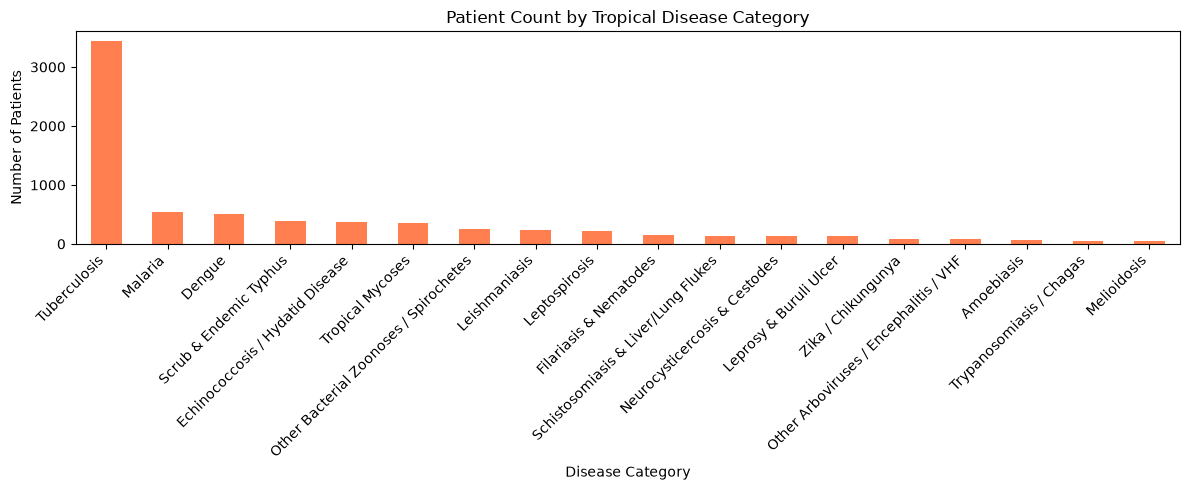

In [23]:
# pathogens_to_track = {
#     "Tuberculosis": ["tuberculosis", "mycobacterium", "tb", "acid-fast", "pott"],
#     "Dengue": ["dengue", "dhf", "dengue shock"],
#     "Malaria": ["malaria", "plasmodium", "falciparum", "vivax"],
#     "Melioidosis": ["melioidosis", "burkholderia pseudomallei"],
#     "Leishmaniasis": ["leishmania", "kala-azar", "donovani"],
#     "Schistosomiasis": ["schistosoma", "schistosomiasis", "bilharzia"],
#     "Leptospirosis": ["leptospir", "weil disease"],
#     "Scrub Typhus": ["scrub typhus", "tsutsugamushi", "orientia"],
#     "Zika / Chikungunya": ["zika", "chikungunya"],
#     "Amoebiasis": ["amoebiasis", "amebiasis", "entamoeba histolytica"],
#     "Filariasis / Helminths": ["filariasis", "strongyloides", "echinococcus", "cysticercosis"]
# }
# pathogens_to_track = {
#     # --- Mycobacterial & Bacterial ---
#     "Tuberculosis": [
#         "tuberculosis", "mycobacterium", "tb", "tuberculoma", 
#         "acid-fast", "pott disease", "scrofula"
#     ],
#     "Melioidosis": [
#         "melioidosis", "burkholderia", "whitmore"
#     ],
#     "Leptospirosis": [
#         "leptospir", "weil disease"
#     ],
#     "Scrub & Endemic Typhus": [
#         "scrub typhus", "tsutsugamushi", "orientia", "rickettsia", "eschar"
#     ],
#     "Leprosy & Buruli Ulcer": [
#         "leprosy", "hansen disease", "buruli ulcer", "mycobacterium ulcerans"
#     ],

#     # --- Arboviral & Viral Hemorrhagic Fevers ---
#     "Dengue": [
#         "dengue", "dhf", "dss", "breakbone"
#     ],
#     "Zika / Chikungunya": [
#         "zika", "chikungunya", "microcephaly"
#     ],
#     "Other Arboviruses / Encephalitis": [
#         "yellow fever", "japanese encephalitis", "crimean-congo", "lassa fever", "ebola"
#     ],

#     # --- Protozoan ---
#     "Malaria": [
#         "malaria", "plasmodium", "falciparum", "vivax", "gametocyte", "blackwater"
#     ],
#     "Leishmaniasis": [
#         "leishmania", "kala-azar", "kala azar", "donovani", "amastigote", "ld bodies"
#     ],
#     "Amoebiasis": [
#         "amoebiasis", "amebiasis", "entamoeba histolytica", "amoebic liver abscess", "amebic abscess"
#     ],
#     "Trypanosomiasis / Chagas": [
#         "trypanosoma", "chagas", "cruzi", "sleeping sickness"
#     ],

#     # --- Tissue Parasites & Flukes (High Imaging Yield) ---
#     "Neurocysticercosis & Cestodes": [
#         "cysticercosis", "neurocysticercosis", "taenia solium", "cysticerci", "scolex"
#     ],
#     "Echinococcosis / Hydatid Disease": [
#         "echinococcus", "echinococcosis", "hydatid", "water lily sign"
#     ],
#     "Schistosomiasis & Liver/Lung Flukes": [
#         "schistosoma", "schistosomiasis", "bilharzia", 
#         "paragonimus", "paragonimiasis", "fasciola", "fascioliasis", "clonorchis"
#     ],
#     "Filariasis & Nematodes": [
#         "filariasis", "wuchereria", "elephantiasis", "filarial dance",
#         "strongyloides", "strongyloidiasis", "loiasis", "loa loa", "onchocerca"
#     ],

#     # --- Endemic Deep & Subcutaneous Tropical Mycoses ---
#     "Tropical Mycoses": [
#         "mycetoma", "madura foot", "madurella", "chromoblastomycosis",
#         "talaromyces", "talaromycosis", "penicillium marneffei",
#         "paracoccidioidomycosis", "histoplasmosis", "sporotrichosis"
#     ]
# }


pathogens_to_track = {
    # --------------------------------------------------------------------------
    # 1. MYCOBACTERIAL & BACTERIAL ZOONOSES
    # --------------------------------------------------------------------------
    "Tuberculosis": [
        "tuberculosis", "mycobacterium tuberculosis", "tuberculoma", "m. tuberculosis",
        "pott disease", "pott's disease", "scrofula", "ghon focus"
    ],
    "Melioidosis": [
        "melioidosis", "burkholderia pseudomallei", "burkholderia", "whitmore"
    ],
    "Leptospirosis": [
        "leptospir", "weil disease", "weil's disease"
    ],
    "Scrub & Endemic Typhus": [
        "scrub typhus", "tsutsugamushi", "orientia", "eschar", "murine typhus", "spotted fever", "rickettsia"
    ],
    "Leprosy & Buruli Ulcer": [
        "leprosy", "mycobacterium leprae", "hansen disease", "hansen's disease",
        "lepromatous", "buruli ulcer", "mycobacterium ulcerans", "bairnsdale ulcer"
    ],
    "Other Bacterial Zoonoses / Spirochetes": [
        "borrelia", "relapsing fever", "treponema pertenue", "yaws", "yersinia pestis", "bubonic plague"
    ],

    # --------------------------------------------------------------------------
    # 2. ARBOVIRUSES & VIRAL HEMORRHAGIC FEVERS
    # --------------------------------------------------------------------------
    "Dengue": [
        "dengue", "dengue hemorrhagic fever", "dengue shock syndrome", "dhf", "dss", "breakbone"
    ],
    "Zika / Chikungunya": [
        "zika", "chikungunya", "congenital zika"
    ],
    "Other Arboviruses / Encephalitis / VHF": [
        "yellow fever", "japanese encephalitis", "crimean-congo", 
        "lassa fever", "ebola virus", "marburg virus", "oropouche", "kyasanur"
    ],

    # --------------------------------------------------------------------------
    # 3. PROTOZOAL INFECTIONS
    # --------------------------------------------------------------------------
    "Malaria": [
        "malaria", "plasmodium", "falciparum", "vivax", "plasmodium ovale", "p. ovale", 
        "knowlesi", "malarial parasite", "blackwater fever", "ring-form trophozoite"
    ],
    "Leishmaniasis": [
        "leishmania", "leishmaniasis", "kala-azar", "kala azar", "donovani", 
        "amastigote", "ld bodies", "leishman-donovan", "cutaneous leishmaniasis"
    ],
    "Amoebiasis": [
        "entamoeba histolytica", "amoebiasis", "amebiasis", "amoebic liver abscess", "amebic abscess"
    ],
    "Trypanosomiasis / Chagas": [
        "trypanosoma", "trypanosomiasis", "chagas disease", "chagasic", "trypanosoma cruzi", 
        "romana sign", "sleeping sickness", "trypanosoma brucei"
    ],

    # --------------------------------------------------------------------------
    # 4. TISSUE PARASITES, FLUKES & HELMINTHS (High Imaging Yield)
    # --------------------------------------------------------------------------
    "Neurocysticercosis & Cestodes": [
        "cysticercosis", "neurocysticercosis", "taenia solium", "cysticerci", "cysticercus", "scolex"
    ],
    "Echinococcosis / Hydatid Disease": [
        "echinococcus", "echinococcosis", "hydatid cyst", "water lily sign"
    ],
    "Schistosomiasis & Liver/Lung Flukes": [
        "schistosoma", "schistosomiasis", "bilharzia", "symmers fibrosis",
        "paragonimiasis", "paragonimus", "pulmonary distomiasis",
        "fasciola", "fascioliasis", "clonorchis", "clonorchiasis", "opisthorchis"
    ],
    "Filariasis & Nematodes": [
        "filariasis", "filarial dance", "wuchereria bancrofti", "brugia malayi", "elephantiasis",
        "loiasis", "loa loa", "onchocerca", "onchocerciasis", "river blindness",
        "strongyloides", "strongyloidiasis", "hyperinfection syndrome",
        "dracunculus", "dracunculiasis", "guinea worm", "gnathostoma", "angiostrongylus"
    ],

    # --------------------------------------------------------------------------
    # 5. ENDEMIC DEEP & SUBCUTANEOUS TROPICAL MYCOSES
    # --------------------------------------------------------------------------
    "Tropical Mycoses": [
        "mycetoma", "madura foot", "madurella", "actinomycetoma", "eumycetoma",
        "chromoblastomycosis", "fonsecaea", "medlar bodies", "muriform cells",
        "talaromyces", "talaromycosis", "penicillium marneffei",
        "paracoccidioidomycosis", "blastomyces", "blastomycosis", "lobomycosis", "lacazia loboi",
        "rhinosporidiosis", "rhinosporidium", "histoplasmosis", "histoplasma capsulatum", 
        "sporotrichosis", "sporothrix"
    ]
}


def identify_diseases(text):
    text_lower = str(text).lower()
    matched = []
    for disease, terms in pathogens_to_track.items():
        if any(term in text_lower for term in terms):
            matched.append(disease)
    return matched if matched else ["Other / Unclassified"]

# Apply across patients
cases_df['identified_diseases'] = cases_df['case_text'].apply(identify_diseases)

# Flatten and count
disease_counts = cases_df.explode('identified_diseases')['identified_diseases'].value_counts()

print("--- Identified Disease Distribution (Patient Level) ---")
print(disease_counts)

plt.figure(figsize=(12, 5))
disease_counts.plot(kind='bar', color='coral')
plt.title("Patient Count by Tropical Disease Category")
plt.xlabel("Disease Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
# 1. Unsplit vs Split captions
if 'split_during_preprocessing' in images_df.columns:
    print("--- Caption Slicing Breakdown ---")
    print(images_df['split_during_preprocessing'].value_counts())
    pct_clean = (images_df['split_during_preprocessing'] == False).mean() * 100
    print(f"Pristine, unsplit captions: {pct_clean:.1f}%")

# 2. Check physical image file existence on disk
image_dir = os.path.join(subset_dir, "images")
if os.path.exists(image_dir):
    actual_files = os.listdir(image_dir)
    print(f"\nPhysical image files present on disk: {len(actual_files):,}")
    if len(actual_files) > 0:
        print("Sample image filename:", actual_files[0])

--- Caption Slicing Breakdown ---
split_during_preprocessing
False    5752
True     3651
Name: count, dtype: int64
Pristine, unsplit captions: 61.2%

Physical image files present on disk: 9
Sample image filename: PMC7


In [ ]:
# # Isolate the unclassified subset
# unclassified_cases = cases_df[
#     cases_df['identified_diseases'].apply(lambda x: "Other / Unclassified" in x or "Other / Unclassified Tropical" in x)
# ]

# print(f"Total unclassified cases: {len(unclassified_cases)}")

# # Find the most frequent non-stopword tokens in their narratives
# from collections import Counter
# import re

# words = []
# for text in unclassified_cases['case_text'].dropna():
#     tokens = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
#     words.extend(tokens)

# # Filter common medical stop words
# medical_stops = {'patient', 'year', 'old', 'presented', 'history', 'with', 'after', 'admission', 'treated', 'clinical', 'hospital', 'examination', 'normal', 'showed'}
# filtered_counts = Counter([w for w in words if w not in medical_stops])

# print("\n--- Top Distinct Words in 'Other / Unclassified' ---")
# for word, count in filtered_counts.most_common(25):
#     print(f"  {word}: {count}")

Total unclassified cases: 0

--- Top Distinct Words in 'Other / Unclassified' ---


In [ ]:
# # The filter strings you used during extraction
# filter_strings = [
#     # Bacterial / Mycobacterial
#     'tuberculosis', 'mycobacterium', 'tuberculoma', 'acid-fast', 'ziehl-neelsen',
#     'pott disease', 'scrofula', 'ghon focus',
#     'melioidosis', 'burkholderia', 'whitmore',
#     'leptospir', 'weil disease',
#     'scrub typhus', 'tsutsugamushi', 'orientia', 'eschar',
#     'leprosy', 'mycobacterium leprae', 'hansen disease', 'lepromatous',
#     'buruli ulcer', 'mycobacterium ulcerans', 'bairnsdale ulcer',
#     'rickettsia', 'murine typhus', 'spotted fever',
#     'borrelia', 'relapsing fever', 'treponema pertenue', 'yaws',
#     'yersinia pestis', 'bubonic plague',

#     # Viruses
#     'dengue', 'dhf', 'dss', 'severe dengue', 'breakbone',
#     'zika', 'microcephaly', 'congenital zika',
#     'chikungunya', 'yellow fever', 'japanese encephalitis',
#     'crimean-congo', 'lassa fever', 'ebola', 'marburg',
#     'oropouche', 'kyasanur', 'alkhurma',

#     # Parasites / Protozoa
#     'malaria', 'plasmodium', 'falciparum', 'vivax', 'malariae', 'ovale', 'knowlesi',
#     'schizont', 'gametocyte', 'ring-form trophozoite', 'blackwater fever',
#     'leishmania', 'leishmaniasis', 'kala-azar', 'kala azar', 'donovani',
#     'amastigote', 'ld bodies', 'leishman-donovan', 'cutaneous leishmaniasis',
#     'entamoeba histolytica', 'amoebiasis', 'amebiasis', 'amoebic liver abscess', 'amebic abscess',
#     'trypanosoma', 'trypanosomiasis', 'chagas', 'chagasic', 'cruzi', 'romana sign',
#     'sleeping sickness', 'brucei',

#     # Helminths / Flukes
#     'cysticercosis', 'neurocysticercosis', 'taenia solium', 'cysticerci', 'scolex',
#     'echinococcus', 'echinococcosis', 'hydatid', 'hydatid cyst', 'water lily sign',
#     'schistosoma', 'schistosomiasis', 'bilharzia', 'symmers fibrosis',
#     'paragonimiasis', 'paragonimus', 'pulmonary distomiasis',
#     'fasciola', 'fascioliasis', 'clonorchis', 'clonorchiasis', 'opisthorchis',
#     'filariasis', 'filarial', 'wuchereria bancrofti', 'brugia', 'elephantiasis',
#     'filarial dance', 'loiasis', 'loa loa', 'onchocerca', 'onchocerciasis', 'river blindness',
#     'strongyloides', 'strongyloidiasis', 'hyperinfection syndrome',
#     'dracunculus', 'dracunculiasis', 'guinea worm',
#     'gnathostoma', 'gnathostomiasis', 'angiostrongylus',

#     # Fungi
#     'mycetoma', 'madura foot', 'madurella', 'actinomycetoma', 'eumycetoma', 'grains',
#     'chromoblastomycosis', 'fonsecaea', 'medlar bodies', 'muriform cells',
#     'talaromyces', 'talaromycosis', 'penicillium marneffei',
#     'paracoccidioidomycosis', 'blastomyces', 'lobomycosis', 'lacazia loboi',
#     'rhinosporidiosis', 'rhinosporidium',
#     'histoplasmosis', 'histoplasma capsulatum', 'sporotrichosis', 'sporothrix'
# ]

# # Identify which specific terms triggered the unclassified cases
# trigger_records = []
# for idx, row in unclassified_cases.iterrows():
#     text = str(row['case_text']).lower()
#     matched_triggers = [s for s in filter_strings if s in text]
#     trigger_records.extend(matched_triggers)

# from collections import Counter
# trigger_counts = Counter(trigger_records)

# print("--- Top Filter Strings Triggering the 955 'Unclassified' Cases ---")
# for term, count in trigger_counts.most_common(20):
#     print(f"  {term:<25}: {count}")

--- Top Filter Strings Triggering the 955 'Unclassified' Cases ---


In [ ]:
# for i, (idx, row) in enumerate(unclassified_cases.head(3).iterrows()):
#     print(f"\n==================== Case #{i+1} (Patient ID: {row.get('patient_id', idx)}) ====================")
#     print(row['case_text'][:600] + "...\n")


==================== Case #1 (Patient ID: 0) ====================
A 7-day-old girl was admitted to our NICU because of a 30-hour intermittent fever with a peak temperature of 38.5 C. Her parents noted that she had a stuffy nose with clear rhinorrhea and choked when feeding over the past two days. She coughed occasionally but had sputum in her throat. Her appetite was unchanged without increasing work of breathing, vomiting, and diarrhea. Her caregivers had confirmed infection of SARS-CoV-2 several days ago. Her mother was healthy during pregnancy but detected fetal hydronephrosis with the right duplex kidney in the third trimester. The baby was born through ...


==================== Case #2 (Patient ID: 8) ====================
A 15-year-old female presented to an outpatient headache clinic with a 10-year history of intractable headache, which had become daily over the past 3 months and also awakened her in the middle of the night. She noted the pain was frontal and radiated to her ne